### BASIC TEXT CLEANING

In [37]:
import pandas as pd
import re

print("IMPORTING LIBRARIES AND LOADING DATA")

# Setting pandas display options for better visibility in Jupyter Notebook
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

# Loading data that should already be downloaded from Kaggle
df = pd.read_csv("../data/raw/realdonaldtrump.csv")
print(df.shape)
df.head()

# Defining a robust text cleaning function
def clean_tweet(text: str) -> str:
    """
    Cleans the input tweet text by:
    - Lowercasing
    - Removing URLs
    - Turning mentions (@username) into a placeholder format (mention_username)
    - Turning hashtags (#hashtag) into a placeholder format (hashtag_hashtag)
    - Removing special characters and emojis
    - Normalizing whitespace
    """
    # Check if the input is a string; if not, return an empty string
    if not isinstance(text, str):
        return ""

    text = text.lower()

    # Remove URLs (http, https, www) and Twitter image links
    text = re.sub(
        r'http\S+|www\.\S+|pic\.twitter\.com/\S+',
        ' ',
        text
    )

    # @CNN -> mention_cnn
    text = re.sub(
        r'@ ([a-z0-9_]+)',
        r' mentions_\1 ',
        text
    )

    # #MAGA -> hashtag_maga
    text = re.sub(
        r'# ([a-z0-9_]+)',
        r' hashtag_\1 ',
        text
    )
    # Remove 'rt ' (Retweet marker) typically found at the start of a tweet
    text = re.sub(r'\brt\b', ' ', text)

    # Remove special characters, keeping only alphanumeric characters, underscores, and whitespace
    # Keep underscore so mention_cnn remains one token
    text = re.sub(r'[^a-z0-9_\s]', ' ', text)

    # Normalize whitespace: replace multiple spaces with a single space and strip leading/trailing spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

print("TEXT CLEANING IN PROGRESS")

# Apply the function to create a NEW column
# We keep the original 'content' column safe
df['cleaned_content'] = df['content'].apply(clean_tweet)

# Display the results to compare original text with the cleaned version
print("Original vs Cleaned Tweets (First 5 rows):")
# Use pandas display functionality to show it nicely in Jupyter
# displaing random 5 rows to see a variety of examples
df_sample = df[['content', 'cleaned_content']].sample(n=5)
display(df_sample)

IMPORTING LIBRARIES AND LOADING DATA
(43352, 8)
TEXT CLEANING IN PROGRESS
Original vs Cleaned Tweets (First 5 rows):


,content,cleaned_content
23843,"Via @ trscoop: ""WHOA: Trump changing venues for Saturday rally in Arizona due to OVERWHELMING RESPONSE""http://therightscoop.com/whoa-trump-changing-venues-for-saturday-rally-in-arizona-due-to-overwhelming-response/ …",via mentions_trscoop whoa trump changing venues for saturday rally in arizona due to overwhelming response
35266,"Just like the NFL, whose ratings have gone WAY DOWN, Nike is getting absolutely killed with anger and boycotts. I wonder if they had any idea that it would be this way? As far as the NFL is concerned, I just find it hard to watch, and always will, until they stand for the FLAG!",just like the nfl whose ratings have gone way down nike is getting absolutely killed with anger and boycotts i wonder if they had any idea that it would be this way as far as the nfl is concerned i just find it hard to watch and always will until they stand for the flag
17622,""" @ joshhobson: Hey, the sign looks good this morning! See it everyday, as I work around the corner at SOUTHCOM. pic.twitter.com/GI37XyFAzP""Thanks",mentions_joshhobson hey the sign looks good this morning see it everyday as i work around the corner at southcom
21758,""" @ tuckahoetommy: If @ realDonaldTrump truly believes he could fix America and loves our Country shouldn't he feel obligated to run?"" Yes!",mentions_tuckahoetommy if mentions_realdonaldtrump truly believes he could fix america and loves our country shouldn t he feel obligated to run yes
12398,@ GlobalGolfPost Thank you.,mentions_globalgolfpost thank you


### LINGUISTIC TEXT CLEANING

In [38]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download required NLTK datasets
# 'punkt' is for tokenization, 'wordnet' for lemmatization
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

# Initialize the tools
base_stop_words = set(stopwords.words('english'))

# Define a set of stop words exceptions that we want to keep in our processed text
base_stop_words_exceptions = {
    "i", "me", "my", "mine",
    "you", "your", "yours",
    "we", "us", "our", "ours",
    "he", "him", "his",
    "she", "her", "hers",
    "they", "them", "their", "theirs",
    "no", "not", "nor", "never",
    "will", "would", "can", "could", "must", "should"
}
# Domain-specific noise words to filter out
twitter_noise_words = {
    "realdonaldtrump",
}
custom_stop_words = base_stop_words - base_stop_words_exceptions | twitter_noise_words
lemmatizer = WordNetLemmatizer()

# Define the NLP processing function
def process_nlp(text: str) -> str:
    """
    Processes the input text by tokenizing, removing stopwords, lemmatizing, and rejoining into a cleaned string.
    """
    # Fallback for empty values
    if not text or not isinstance(text, str):
        return ""

    # A. Tokenization: Split text into a list of individual words
    tokens = word_tokenize(text)

    # B. Stopwords removal and 
    # C. Lemmatization
    # We also remove words that are just 1 character long (e.g., isolated 's' or 't') but keep 'i' as it's a common pronoun
    # Lemmatization reduces words to their base or dictionary form (e.g., "running" -> "run")
    processed_tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in custom_stop_words and (len(word) > 1 or word == "i")
    ]

    # D. Rejoin into a single string
    # (Models like TF-IDF (Term Frequency-Inverse Document Frequency) require string format, not lists)
    return " ".join(processed_tokens)

print("NLP PROCESSING IN PROGRESS")

# Apply the function to create the final processed column
df['processed_content'] = df['cleaned_content'].apply(process_nlp)

# Display the full transformation pipeline
print("\nPipeline Check (Original -> Cleaned -> Processed):")
df_sample = df[['content', 'cleaned_content', 'processed_content']].sample(n=5)
display(df_sample)

NLP PROCESSING IN PROGRESS


[nltk_data] Downloading package punkt to /home/patryk/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/patryk/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /home/patryk/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/patryk/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!



Pipeline Check (Original -> Cleaned -> Processed):


,content,cleaned_content,processed_content
41761,THANK YOU UTAH! # KAG2020pic.twitter.com/LrCvXgmp3X,thank you utah hashtag_kag2020,thank you utah hashtag_kag2020
17837,Congratulations to @ David_Bossie & his team @ Citizens_United on their important court win for the First Amendment! http://abcnews.go.com/Politics/wireStory/citizens-united-show-films-donors-26200992 …,congratulations to mentions_david_bossie his team mentions_citizens_united on their important court win for the first amendment,congratulation mentions_david_bossie his team mentions_citizens_united their important court win first amendment
3070,I win awards for speaking-but the enemies either won't comment or will say only bad...leave Clint alone!,i win awards for speaking but the enemies either won t comment or will say only bad leave clint alone,i win award speaking enemy either comment will say bad leave clint alone
42993,. @ Facebook CEO Mark Zuckerberg is today criticizing Twitter. “We have a different policy than Twitter on this. I believe strongly that Facebook shouldn’t be the arbiter of truth of everything that people say online.” Did Twitter criticize Obama for his “you can keep your Dr.”?,mentions_facebook ceo mark zuckerberg is today criticizing twitter we have a different policy than twitter on this i believe strongly that facebook shouldn t be the arbiter of truth of everything that people say online did twitter criticize obama for his you can keep your dr,mentions_facebook ceo mark zuckerberg today criticizing twitter we different policy twitter i believe strongly facebook arbiter truth everything people say online twitter criticize obama his you can keep your dr
34958,RED WAVE!,red wave,red wave


### ADDING BONUS FEATURES AND EXPORTING CLEANED DATASET

In [39]:
import os

# Calculate the 33rd and 67th percentiles for 'retweets'
p33 = df['retweets'].quantile(0.3333)
p67 = df['retweets'].quantile(0.6667)

# Create a new column 'engagement_level' based on these thresholds
def categorize_engagement(retweets: int) -> str:
    """
    Categorizes engagement level based on retweet counts.
    """
    if retweets <= p33:
        return 'Low'
    elif retweets <= p67:
        return 'Medium'
    else:
        return 'High'

df['engagement_level'] = df['retweets'].apply(categorize_engagement)

# Add the tweet length based on the original 'content' column
df['tweet_length'] = df['content'].astype(str).apply(len)

df['has_hashtag'] = df['content'].str.contains(r'# \w+', regex=True).astype(int)
df['has_mention'] = df['content'].str.contains(r'@ \w+', regex=True).astype(int)

# Define the directory and filename
output_dir = '../data/processed'
output_filename = 'cleaned_realdonaldtrump.csv'

# Create the directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Directory created: {output_dir}")

# Save the dataframe to the specified path
full_path = os.path.join(output_dir, output_filename)
df.to_csv(full_path, index=False)

# Confirm the file was saved and check its size
file_size_mb = os.path.getsize(full_path) / (1024 * 1024)
print(f"Success! Dataset saved at: {full_path}")
print(f"File size: {file_size_mb:.2f} MB")
print("Engagement labels and binary metadata flags added successfully!")

Success! Dataset saved at: ../data/processed/cleaned_realdonaldtrump.csv
File size: 20.36 MB
Engagement labels and binary metadata flags added successfully!


### GENERATING WORDCLOUD

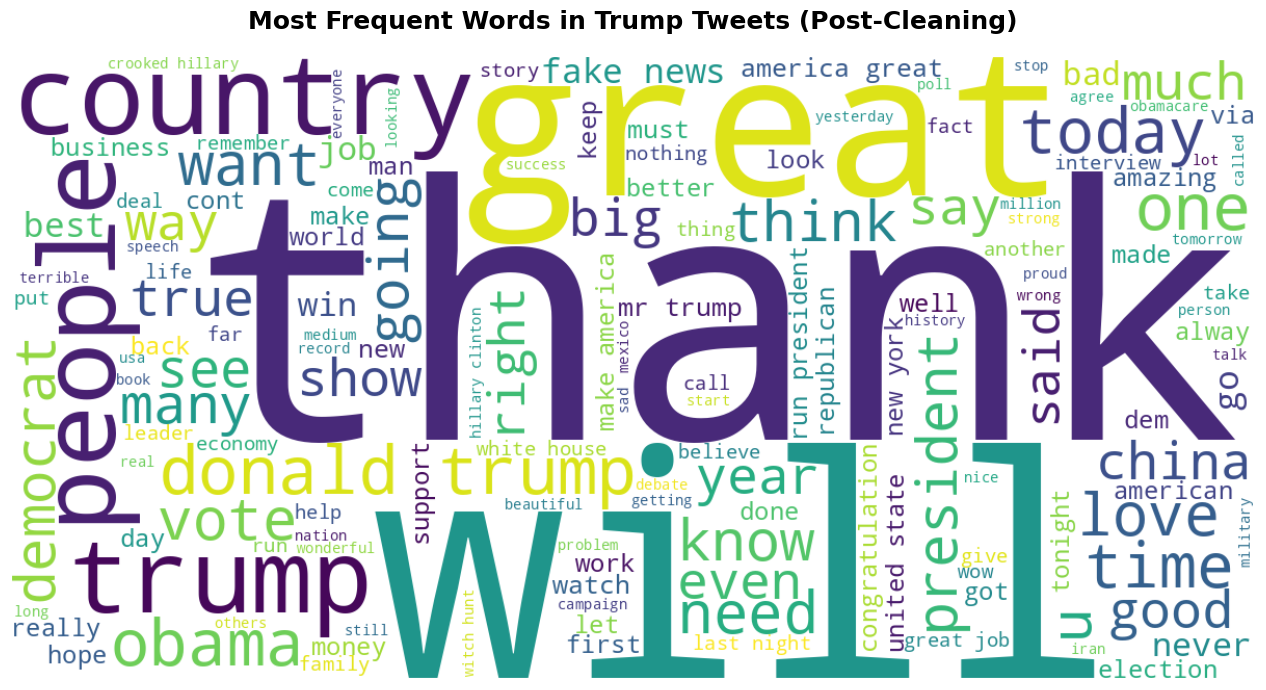

In [40]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Combine all processed tweets into one massive string
# We use 'processed_content' because it is already free of stopwords, links, and punctuation
all_words = ' '.join(text for text in df['processed_content'] if isinstance(text, str))

# remove mentions and hashtags from the word cloud to focus on the core content
all_words = re.sub(r'\bmentions_[a-z0-9_]+\b', ' ', all_words)
all_words = re.sub(r'\bhashtag_[a-z0-9_]+\b', ' ', all_words)

# Configure and generate the WordCloud
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='viridis',  # 'viridis' or 'plasma'
    max_words=150,       # Display the top 150 most frequent words
).generate(all_words)

# Plot the WordCloud
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Turn off the axes for a cleaner look
plt.title('Most Frequent Words in Trump Tweets (Post-Cleaning)', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [41]:
from collections import Counter

# Combine all processed tweets into a list of words
# We skip empty strings to be clean
all_words = ' '.join(df['processed_content'].fillna("").astype(str)).split()

# remove mentions and hashtags from the word list to focus on the core content
all_words = [word for word in all_words if not re.match(r'\bmentions_[a-z0-9_]+\b', word) and not re.match(r'\bhashtag_[a-z0-9_]+\b', word)]

# Count the frequencies
word_counts = Counter(all_words)

# Get the top 20 most frequent words
top_20 = word_counts.most_common(20)

print("TOP 20 MOST FREQUENT WORDS")
for word, count in top_20:
    print(f"{word}: {count}")

TOP 20 MOST FREQUENT WORDS
i: 10794
you: 10715
great: 6763
will: 6678
trump: 5533
we: 5034
our: 4597
he: 4451
they: 3848
my: 3835
not: 3634
thank: 3060
president: 3022
people: 2727
your: 2683
can: 2622
no: 2382
thanks: 2333
country: 2314
get: 2160
